<a href="https://colab.research.google.com/github/kamxsato/MIS444_Final_Project/blob/main/24104087_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phone Addiction Prediction
## Course: MIS444 — Predictive Analytics in Business

**Problem Type:** Classification — Predicting a binary variable (Addicted Label)

**Dataset Source:** [Kaggle — Predicting Smartphone Addiction](https://www.kaggle.com/competitions/playground-series-s6e8/data)

---
### Project Outline
1. Data Collection
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Selection
5. Model Building
6. Model Optimization
7. Model Evaluation & Validation
8. Business Insights & Recommendations

# 0. Libraries

In [51]:
# 0.1 import libraries
import pandas as pd
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats.mstats import winsorize
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from imblearn.over_sampling import SMOTE
from scipy.stats import chi2_contingency, pearsonr, spearmanr
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score,
                             precision_score, recall_score, f1_score, make_scorer)


drive.mount('/content/drive', force_remount=True)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
warnings.filterwarnings('ignore')

print(f'Libraries Loaded')

Mounted at /content/drive
Libraries Loaded


# 1. Load Data

In [2]:
# 1.1 load dataset
df = pd.read_csv('/content/drive/MyDrive/死/Summer 2026/MIS444/Project/train.csv')

print(f"✅ Dataset loaded. Shape: {df.shape}")
display(df)

✅ Dataset loaded. Shape: (691369, 14)


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1


In [3]:
# 1.2 inspect data

overview_df = pd.DataFrame({
    'dtype': df.dtypes,
    'nunique': df.nunique(),
    'nulls': df.isnull().sum(),
    'null_%': (df.isnull().mean()*100).round(2),
    'sample': [df[c].dropna().iloc[0] if df[c].notna().any() else 'ALL NULL' for c in df.columns]
})

print(f'=== overview ===')
display(overview_df)
print(f'Shape: {df.shape}')

=== overview ===


,dtype,nunique,nulls,null_%,sample
id,int64,691369,0,0.00,0
age,float64,18,28929,4.18,24.0
daily_screen_time_hours,float64,1389,95854,13.86,5.97
social_media_hours,float64,721,133995,19.38,1.83
gaming_hours,float64,401,126821,18.34,1.59
work_study_hours,float64,600,51518,7.45,2.11
sleep_hours,float64,451,44480,6.43,7.46
notifications_per_day,float64,231,67584,9.78,122.0
app_opens_per_day,float64,166,80710,11.67,38.0
weekend_screen_time,float64,1437,112063,16.21,8.63


Shape: (691369, 14)


In [4]:
display(df.describe(include='all').T)
print(f'Shape: {df.shape}')

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,691369.0,NaN,NaN,NaN,345684.0,199581.183466,0.0,172842.0,345684.0,518526.0,691368.0
age,662440.0,NaN,NaN,NaN,26.615408,5.153162,18.0,22.0,27.0,31.0,35.0
daily_screen_time_hours,595515.0,NaN,NaN,NaN,7.640865,2.721446,0.5,5.48,7.77,9.84,15.0
social_media_hours,557374.0,NaN,NaN,NaN,2.471038,1.316137,0.0,1.45,2.31,3.37,8.0
gaming_hours,564548.0,NaN,NaN,NaN,1.459265,0.934552,0.0,0.7,1.33,2.09,4.0
work_study_hours,639851.0,NaN,NaN,NaN,2.366971,1.258797,0.0,1.36,2.2,3.2,6.0
sleep_hours,646889.0,NaN,NaN,NaN,6.804334,1.234512,4.5,5.78,6.8,7.87,9.0
notifications_per_day,623785.0,NaN,NaN,NaN,145.8949,65.917556,20.0,93.0,150.0,204.0,250.0
app_opens_per_day,610659.0,NaN,NaN,NaN,102.636781,48.09397,15.0,64.0,104.0,145.0,180.0
weekend_screen_time,579306.0,NaN,NaN,NaN,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


Shape: (691369, 14)


# 2. Preprocessing

In [5]:
# 2.1 Missing Values
# 2.1.1 Missing values detection

missing_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)
missing_df[missing_df['Missing Count'] > 0]

print(f'=== missing value ===')
display(missing_df)
print(f'Shape: {df.shape}')

=== missing value ===


,Data Type,Missing Count,Missing %
social_media_hours,float64,133995,19.38
gaming_hours,float64,126821,18.34
weekend_screen_time,float64,112063,16.21
daily_screen_time_hours,float64,95854,13.86
app_opens_per_day,float64,80710,11.67
notifications_per_day,float64,67584,9.78
stress_level,object,55148,7.98
work_study_hours,float64,51518,7.45
sleep_hours,float64,44480,6.43
academic_work_impact,object,44224,6.40


Shape: (691369, 14)


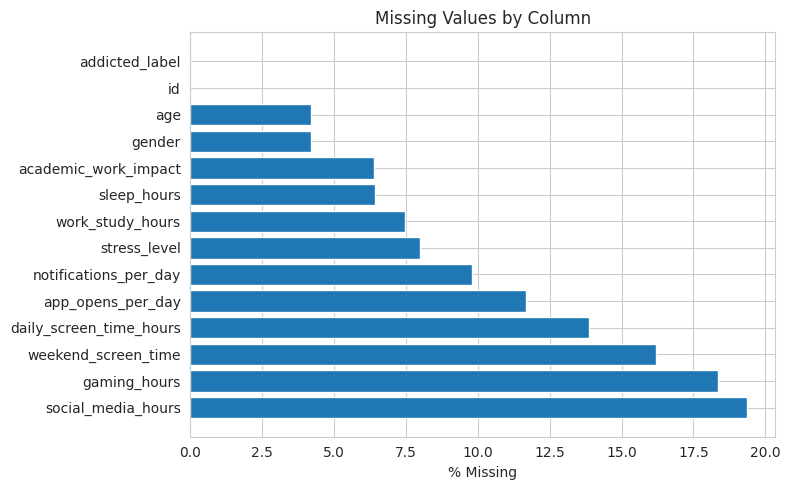

Shape: (691369, 14)


In [6]:
# 2.1.2 missing data visualisation

fig, axes = plt.subplots(figsize=(8, 5))
plt.barh(missing_df.index, missing_df['Missing %'])
plt.xlabel('% Missing')
plt.title('Missing Values by Column')
plt.tight_layout()
plt.show()
print(f'Shape: {df.shape}')

In [7]:
# 2.1.3 missing value treatment
# Median for numeric data with less than 10% missing data

missing_cols = ['age', 'sleep_hours', 'work_study_hours', 'notifications_per_day']

missing_cols_median = df[missing_cols].median()
df[missing_cols] = df[missing_cols].fillna(missing_cols_median)

print(f'Missing values Imputed')

Missing values Imputed


In [8]:
# Iterative Imputation for missing value greater than 10%

missing_cols1 = ['app_opens_per_day', 'daily_screen_time_hours',
                 'weekend_screen_time', 'gaming_hours', 'social_media_hours']

df[missing_cols1] = IterativeImputer(max_iter=10, random_state=42).fit_transform(df[missing_cols1])

print(f'Missing values Imputed')

Missing values Imputed


In [9]:
# Mode for categorical data
df['stress_level'] = df['stress_level'].fillna(df['stress_level'].mode()[0])
df['academic_work_impact'] = df['academic_work_impact'].fillna(df['academic_work_impact'].mode()[0])
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

print(f'Missing values Imputed')

Missing values Imputed


In [10]:
# 2.1.4 missing values after imputation

missing_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)
missing_df[missing_df['Missing Count'] > 0]

print(f'=== missing value (after treatment) ===')
display(missing_df)
print(f'Shape: {df.shape}')

=== missing value (after treatment) ===


,Data Type,Missing Count,Missing %
id,int64,0,0.0
age,float64,0,0.0
daily_screen_time_hours,float64,0,0.0
social_media_hours,float64,0,0.0
gaming_hours,float64,0,0.0
work_study_hours,float64,0,0.0
sleep_hours,float64,0,0.0
notifications_per_day,float64,0,0.0
app_opens_per_day,float64,0,0.0
weekend_screen_time,float64,0,0.0


Shape: (691369, 14)


In [11]:
# 2.2 Duplicates
# 2.2.1 Duplicate value detection

n_dupes_df = df.duplicated().sum()

print(f'Exact duplicate rows: {n_dupes_df}')

Exact duplicate rows: 0


In [12]:
# 2.3 Outliers
# 2.3.1 Outlier Detection using IQR

num_cols = ['age', 'daily_screen_time_hours', 'social_media_hours',
            'gaming_hours', 'work_study_hours', 'sleep_hours',
            'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']

def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

print('IQR Outlier Bounds:')
for col in num_cols:
    lo, hi = iqr_bounds(df[col].dropna())
    n_out  = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f'  {col:<15} lower={lo:>10.2f}  upper={hi:>10.2f}  outliers={n_out}')

IQR Outlier Bounds:
  age             lower=      8.50  upper=     44.50  outliers=0
  daily_screen_time_hours lower=     -0.68  upper=     16.00  outliers=0
  social_media_hours lower=     -1.07  upper=      5.89  outliers=3900
  gaming_hours    lower=     -0.98  upper=      3.77  outliers=7192
  work_study_hours lower=     -1.12  upper=      5.64  outliers=6634
  sleep_hours     lower=      2.98  upper=     10.66  outliers=0
  notifications_per_day lower=    -40.50  upper=    339.50  outliers=0
  app_opens_per_day lower=    -38.50  upper=    245.50  outliers=0
  weekend_screen_time lower=      1.26  upper=     17.82  outliers=99


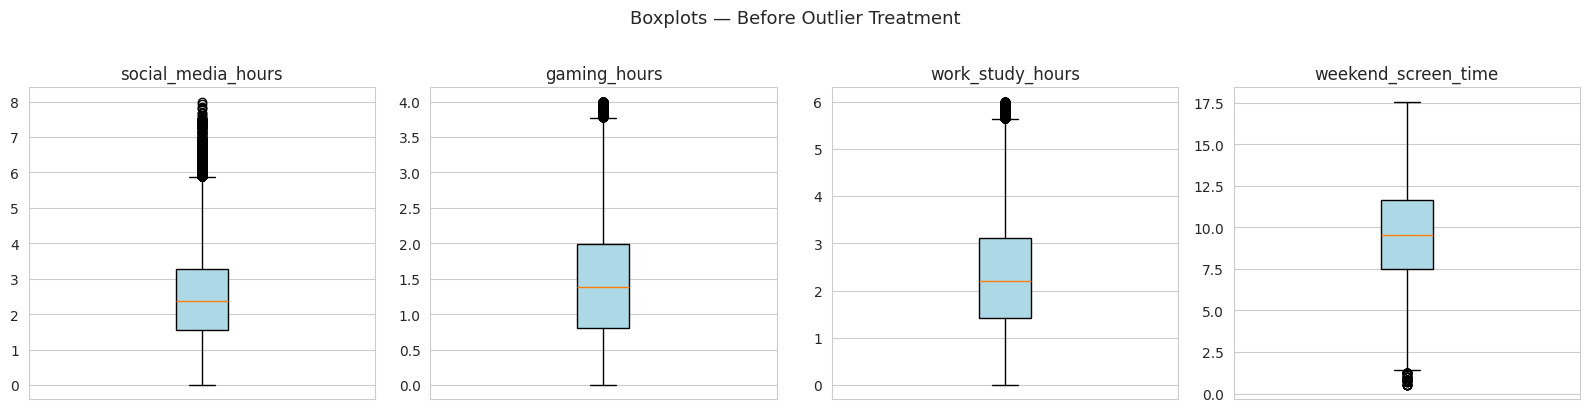

Shape: (691369, 14)


In [13]:
# 2.3.2 Outlier visualization using Boxplots
num_cols_outl = ['social_media_hours', 'gaming_hours', 'work_study_hours', 'weekend_screen_time']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, num_cols_outl):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(col)
    ax.set_xticks([])

plt.suptitle('Boxplots — Before Outlier Treatment', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()
print(f'Shape: {df.shape}')

In [14]:
# 2.3.3 Outlier treatment using capping (winsorization)

for col in num_cols_outl:
    df[col] = np.asarray(winsorize(df[col], limits= (0.05, 0.05)))

In [15]:
# 2.3.4 IQR after outlier treatment

def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

print('IQR Outlier Bounds:')
for col in num_cols_outl:
    lo, hi = iqr_bounds(df[col].dropna())
    n_out  = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f'  {col:<15} lower={lo:>10.2f}  upper={hi:>10.2f}  outliers={n_out}')

IQR Outlier Bounds:
  social_media_hours lower=     -1.07  upper=      5.89  outliers=0
  gaming_hours    lower=     -0.98  upper=      3.77  outliers=0
  work_study_hours lower=     -1.12  upper=      5.64  outliers=0
  weekend_screen_time lower=      1.26  upper=     17.82  outliers=0


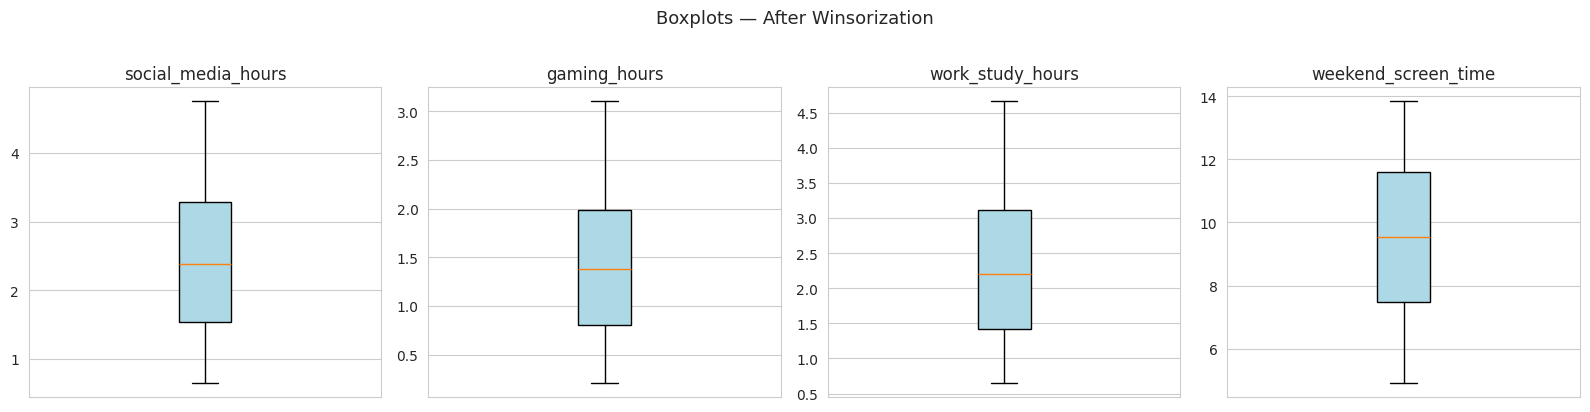

Shape: (691369, 14)


In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, num_cols_outl):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(col)
    ax.set_xticks([])

plt.suptitle('Boxplots — After Winsorization', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()
print(f'Shape: {df.shape}')

In [17]:
# 2.5 Encode Categorial data
# 2.5.1 Encode gender using One-hot encoding

df['gender_encoded'] = df['gender']

df = pd.get_dummies(
    df,
    columns = ['gender_encoded'],
    drop_first = False,
    dtype=int
)

print(f'Categories encoded')

Categories encoded


In [18]:
# 2.5.2 Encode stress_level using ordinal encoding

df['stress_level_encoded'] = OrdinalEncoder(categories=[['Low', 'Medium', 'High']]).fit_transform(df[['stress_level']])

print(f'Categories encoded')

Categories encoded


In [19]:
# 2.5.3 Encode academic_work_impact using label encoder

df['academic_work_impact_n'] = LabelEncoder().fit_transform(df['academic_work_impact'])

print(f'Categories encoded')

Categories encoded


In [20]:
# 2.6 Scaling

non_num_cols = ['id', 'gender', 'stress_level', 'academic_work_impact',
                'gender_encoded_Female', 'gender_encoded_Male',
                'gender_encoded_Other', 'stress_level_encoded', 'academic_work_impact_n']

df_scaled = pd.DataFrame(StandardScaler().fit_transform(df[num_cols]), columns=num_cols, index=df.index)

df_scaled = pd.concat([df_scaled, df[non_num_cols], df['addicted_label']], axis=1)

display(df_scaled)

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,id,gender,stress_level,academic_work_impact,gender_encoded_Female,gender_encoded_Male,gender_encoded_Other,stress_level_encoded,academic_work_impact_n,addicted_label
0,-0.521628,-0.323040,-0.545779,0.178694,-0.197940,0.549303,-0.387965,-1.429761,-0.326267,0,Male,Medium,No,0,1,0,1.0,0,1
1,-1.512751,-0.631740,-1.197704,-0.050753,0.612704,1.185745,-1.122500,-1.850019,-0.547691,1,Female,Medium,No,1,0,0,1.0,0,0
2,-1.710976,-0.964062,-0.667787,-0.462953,-0.118638,-0.463979,-0.196347,-0.943147,-0.772079,2,Female,Low,Yes,1,0,0,0.0,1,0
3,-1.116302,-0.461803,-1.041242,-0.030931,0.903478,1.713321,-0.547646,-0.191106,-0.314737,3,Other,Low,Yes,0,0,1,0.0,1,1
4,-0.125179,1.343309,-0.511010,1.683061,-0.338922,-1.301402,0.059143,0.045696,1.503102,4,Female,Medium,No,1,0,0,1.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,-0.918077,1.184701,0.688531,0.154032,-0.603262,0.758659,-0.962818,-0.191106,1.310942,691364,Male,High,No,0,1,0,2.0,0,1
691365,-1.314527,-1.583389,-0.519702,-0.684467,-1.484397,-0.179255,1.192881,-1.341286,-0.387758,691365,Female,High,No,1,0,0,2.0,0,1
691366,0.073046,-0.518583,-0.344966,-0.234350,-0.241997,-0.539347,0.059143,-0.368057,-0.649096,691366,Other,Medium,No,0,0,1,1.0,0,1
691367,-0.918077,1.562340,1.070994,-1.498305,-0.867602,-1.066923,0.394474,-0.898909,-0.679842,691367,Other,High,Yes,0,0,1,2.0,1,1


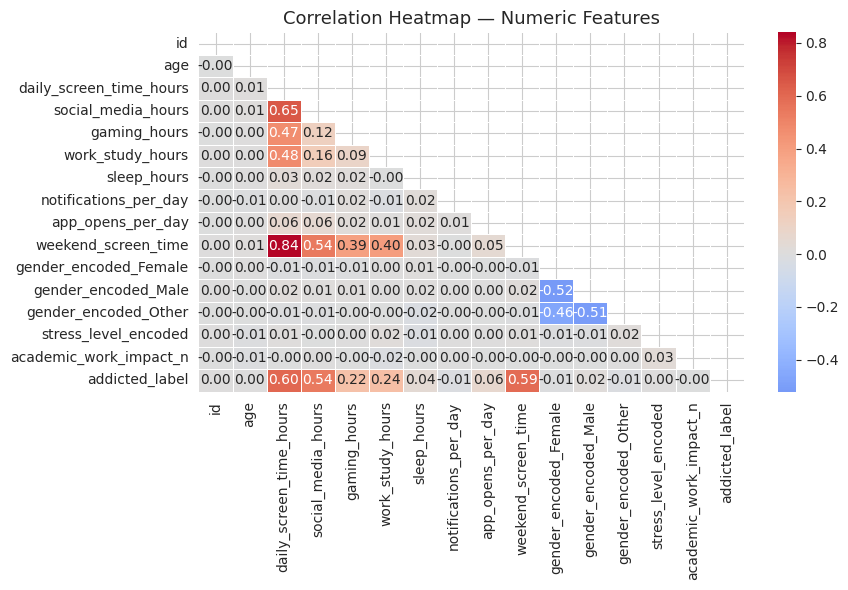

In [21]:
# 2.7 Multicolinearity check

corr_cols = ['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
             'gaming_hours', 'work_study_hours', 'sleep_hours',
             'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
            'gender_encoded_Female', 'gender_encoded_Male', 'gender_encoded_Other',
             'stress_level_encoded', 'academic_work_impact_n', 'addicted_label']

corr_matrix = df_scaled[corr_cols].corr()

plt.figure(figsize=(9, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()

# 3. EDA

In [22]:
# 3.1 Numeric summary statistics + skewness & kurtosis

num_cols_df = df.select_dtypes(include='number').columns.tolist()
stats_df = df[num_cols_df].agg(['mean','median','std','skew']).T
stats_df['kurtosis'] = df[num_cols_df].kurtosis()
stats_df['cv_%'] = (df[num_cols_df].std() / df[num_cols_df].mean() * 100).round(2)

print(f'summary statistics')
display(stats_df.round(3))
print(f'Shape: {df.shape}')

summary statistics


,mean,median,std,skew,kurtosis,cv_%
id,345684.000,345684.000,199581.183,0.000,-1.200,57.74
age,26.632,27.000,5.045,-0.047,-1.140,18.94
daily_screen_time_hours,7.643,7.750,2.648,-0.122,-0.851,34.65
social_media_hours,2.458,2.380,1.150,0.306,-0.790,46.81
gaming_hours,1.445,1.380,0.811,0.373,-0.708,56.12
work_study_hours,2.335,2.200,1.135,0.430,-0.703,48.61
sleep_hours,6.804,6.800,1.194,-0.006,-1.000,17.55
notifications_per_day,146.296,150.000,62.625,-0.237,-0.923,42.81
app_opens_per_day,102.640,103.332,45.210,-0.135,-0.926,44.05
weekend_screen_time,9.479,9.539,2.602,-0.072,-1.040,27.45


Shape: (691369, 19)


gaming_hours, social_media_hours and work_study_hours are positively skewed

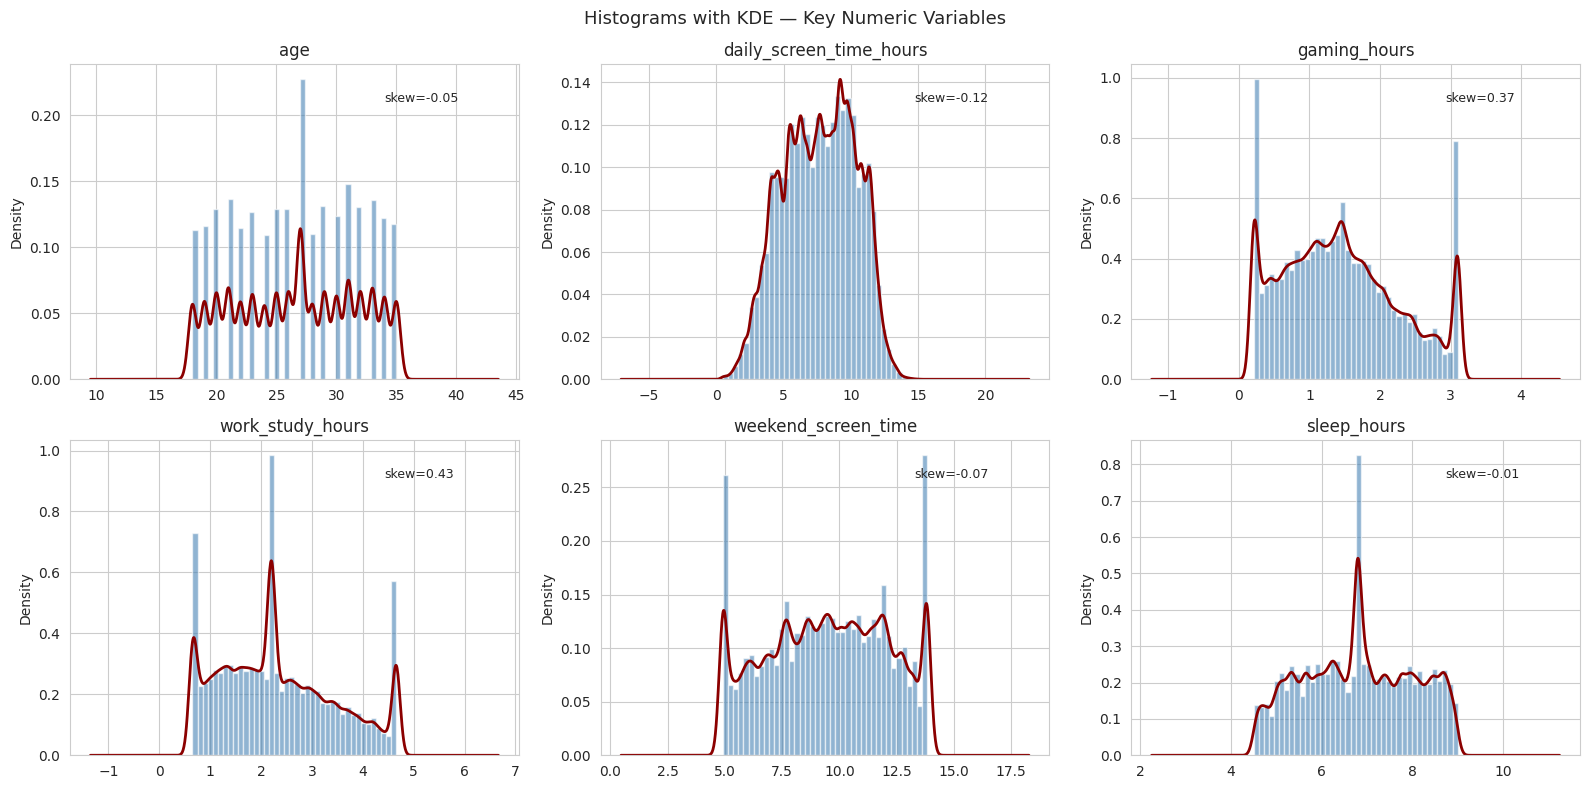

In [23]:
# 3.2 Histogram + KDE on key numeric columns

key_num = ['age','daily_screen_time_hours','gaming_hours',
           'work_study_hours','weekend_screen_time','sleep_hours']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, key_num):
    df[col].hist(bins=40, density=True, alpha=0.6, color='steelblue', edgecolor='white', ax=ax)
    df[col].plot.kde(ax=ax, color='darkred', linewidth=2)
    ax.set_title(col)
    ax.set_ylabel('Density')
    skew = df[col].skew()
    ax.annotate(f'skew={skew:.2f}', xy=(0.7,0.88), xycoords='axes fraction', fontsize=9)
plt.suptitle('Histograms with KDE — Key Numeric Variables', fontsize=13)
plt.tight_layout()
plt.show()

No severe skewness detected

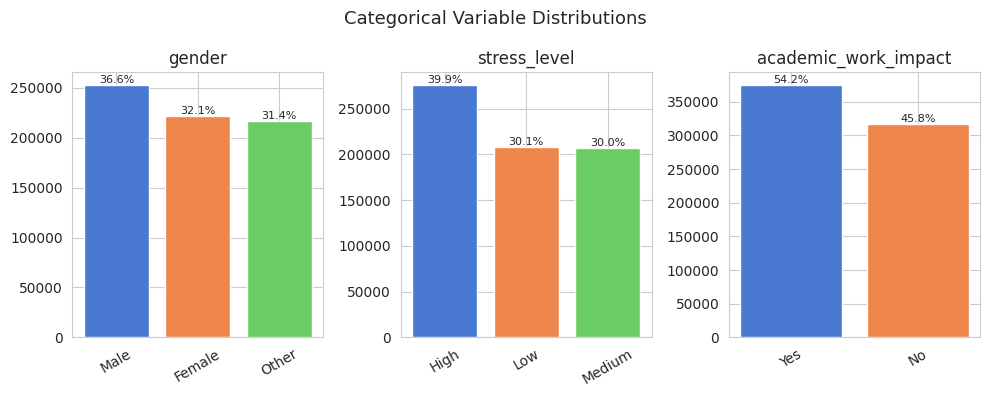

In [24]:
# 3.3 Bar Charts for categorical columns
cat_cols = ['gender','stress_level','academic_work_impact']
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, col in zip(axes.flat, cat_cols):
    vc = df[col].value_counts()
    bars = ax.bar(vc.index, vc.values, color=sns.color_palette('muted', len(vc)))
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
    total = vc.sum()
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                f'{val/total*100:.1f}%', ha='center', va='bottom', fontsize=8)
plt.suptitle('Categorical Variable Distributions', fontsize=13)
plt.tight_layout()
plt.show()

no extreme biases detected

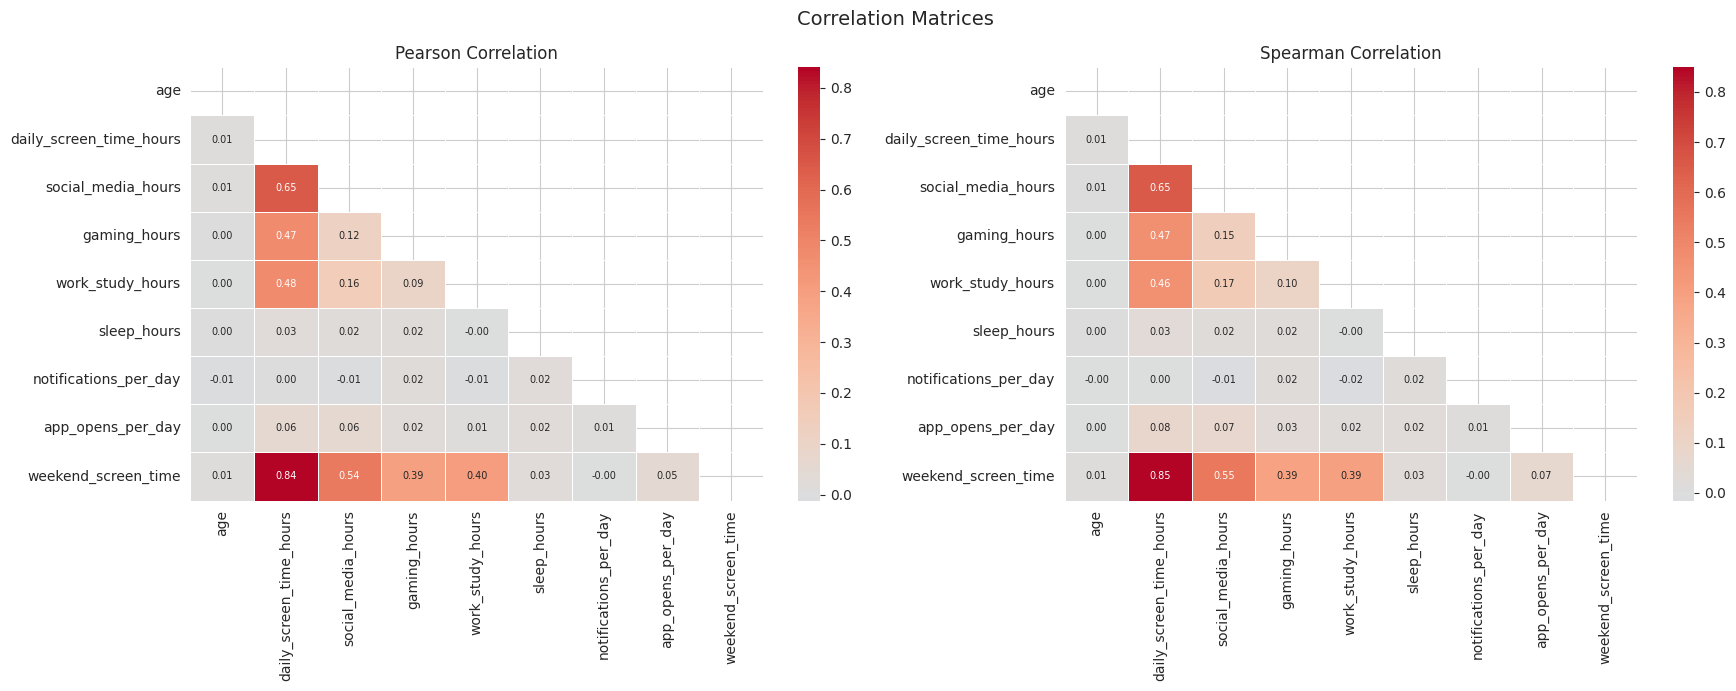

In [25]:
# 3.5 Pearson & Spearman correlation matrices

corr_cols = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
             'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day',
             'weekend_screen_time', 'addicted_label']

pearson  = df[num_cols].corr(method='pearson')
spearman = df[num_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, mat, title in zip(axes, [pearson, spearman], ['Pearson','Spearman']):
    mask = np.triu(np.ones_like(mat, dtype=bool))
    sns.heatmap(mat, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.4, annot_kws={'size':7}, ax=ax)
    ax.set_title(f'{title} Correlation', fontsize=12)
plt.suptitle('Correlation Matrices', fontsize=14)
plt.tight_layout()
plt.show()

spearmann correlation suggests multicolinearity

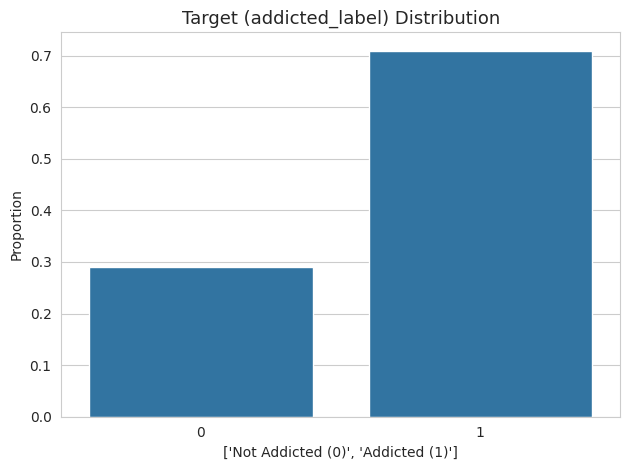

In [58]:
# 3.6 Target spread

target_counts = df['addicted_label'].value_counts(normalize=True)
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.title('Target (addicted_label) Distribution', fontsize=13)
plt.ylabel('Proportion')
plt.xlabel(['Not Addicted (0)', 'Addicted (1)'])

plt.tight_layout()
plt.show()

Chi-square (gender, stress): χ²=230.97, p=0.0000, dof=4
Reject H₀ (independent)
Chi-square (gender, academic impact): χ²=12.65, p=0.0018, dof=2
Reject H₀ (independent)
Chi-square (academic impact, stress): χ²=715.65, p=0.0000, dof=2
Reject H₀ (independent)
Chi-square (stress, academic impact): χ²=715.65, p=0.0000, dof=2
Reject H₀ (independent)


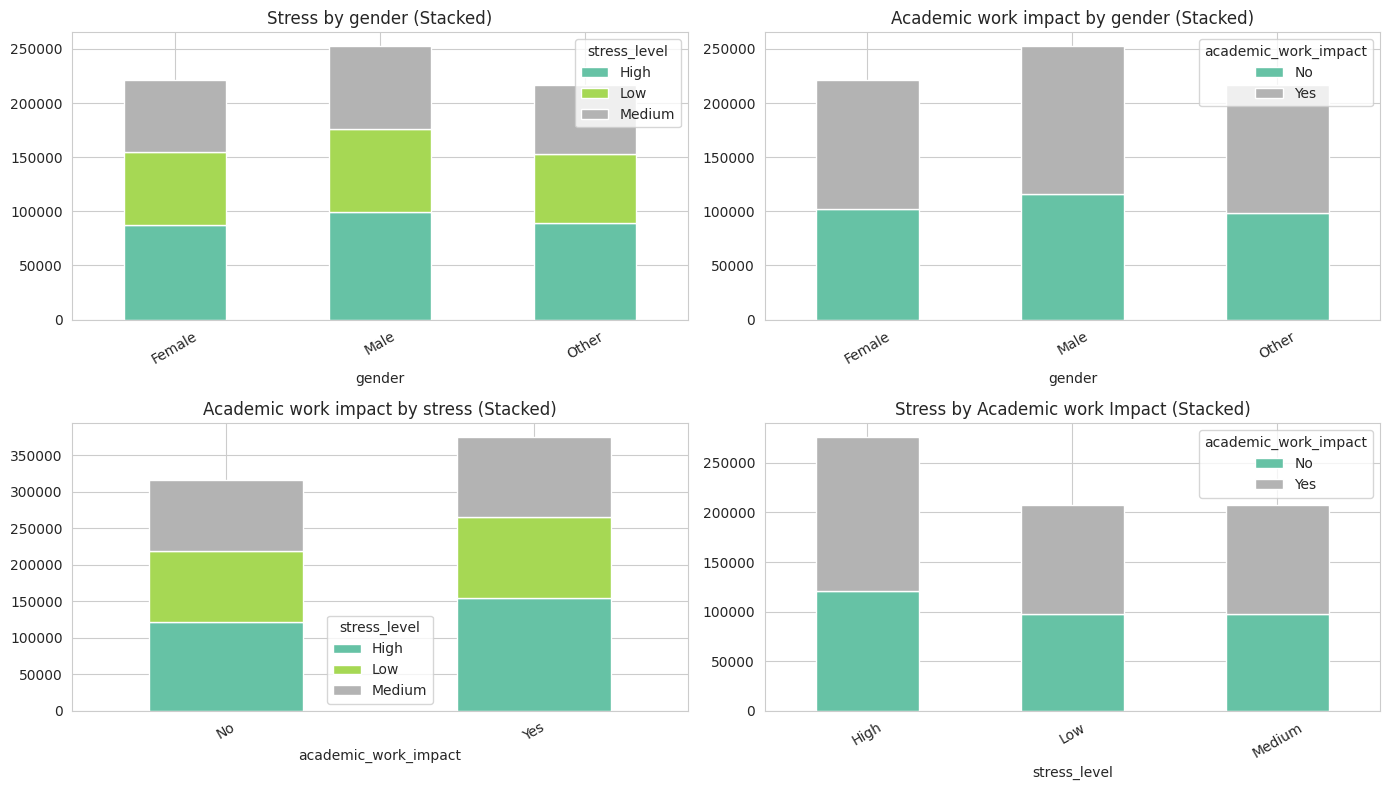

In [26]:
# 3.6 Chi-Square test

ct1 = pd.crosstab(df['gender'], df['stress_level'])
ct2 = pd.crosstab(df['gender'], df['academic_work_impact'])
ct3 = pd.crosstab(df['academic_work_impact'], df['stress_level'])
ct4 = pd.crosstab(df['stress_level'], df['academic_work_impact'])

chi2, p, dof, expected = chi2_contingency(ct1)
print(f'Chi-square (gender, stress): χ²={chi2:.2f}, p={p:.4f}, dof={dof}')
print('Reject H₀ (independent)' if p < 0.05 else 'Fail to reject H₀')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
ct1.plot(kind='bar', stacked=True, ax=axes[0,0], colormap='Set2')
axes[0,0].set_title('Stress by gender (Stacked)')
axes[0,0].tick_params(axis='x', rotation=30)

chi2, p, dof, expected = chi2_contingency(ct2)
print(f'Chi-square (gender, academic impact): χ²={chi2:.2f}, p={p:.4f}, dof={dof}')
print('Reject H₀ (independent)' if p < 0.05 else 'Fail to reject H₀')

ct2.plot(kind='bar', stacked=True, ax=axes[0,1], colormap='Set2')
axes[0,1].set_title('Academic work impact by gender (Stacked)')
axes[0,1].tick_params(axis='x', rotation=30)

chi2, p, dof, expected = chi2_contingency(ct3)
print(f'Chi-square (academic impact, stress): χ²={chi2:.2f}, p={p:.4f}, dof={dof}')
print('Reject H₀ (independent)' if p < 0.05 else 'Fail to reject H₀')

ct3.plot(kind='bar', stacked=True, ax=axes[1,0], colormap='Set2')
axes[1,0].set_title('Academic work impact by stress (Stacked)')
axes[1,0].tick_params(axis='x', rotation=30)

chi2, p, dof, expected = chi2_contingency(ct4)
print(f'Chi-square (stress, academic impact): χ²={chi2:.2f}, p={p:.4f}, dof={dof}')
print('Reject H₀ (independent)' if p < 0.05 else 'Fail to reject H₀')

ct4.plot(kind='bar', stacked=True, ax=axes[1,1], colormap='Set2')
axes[1,1].set_title('Stress by Academic work Impact (Stacked)')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

low p-values suggest good predictability

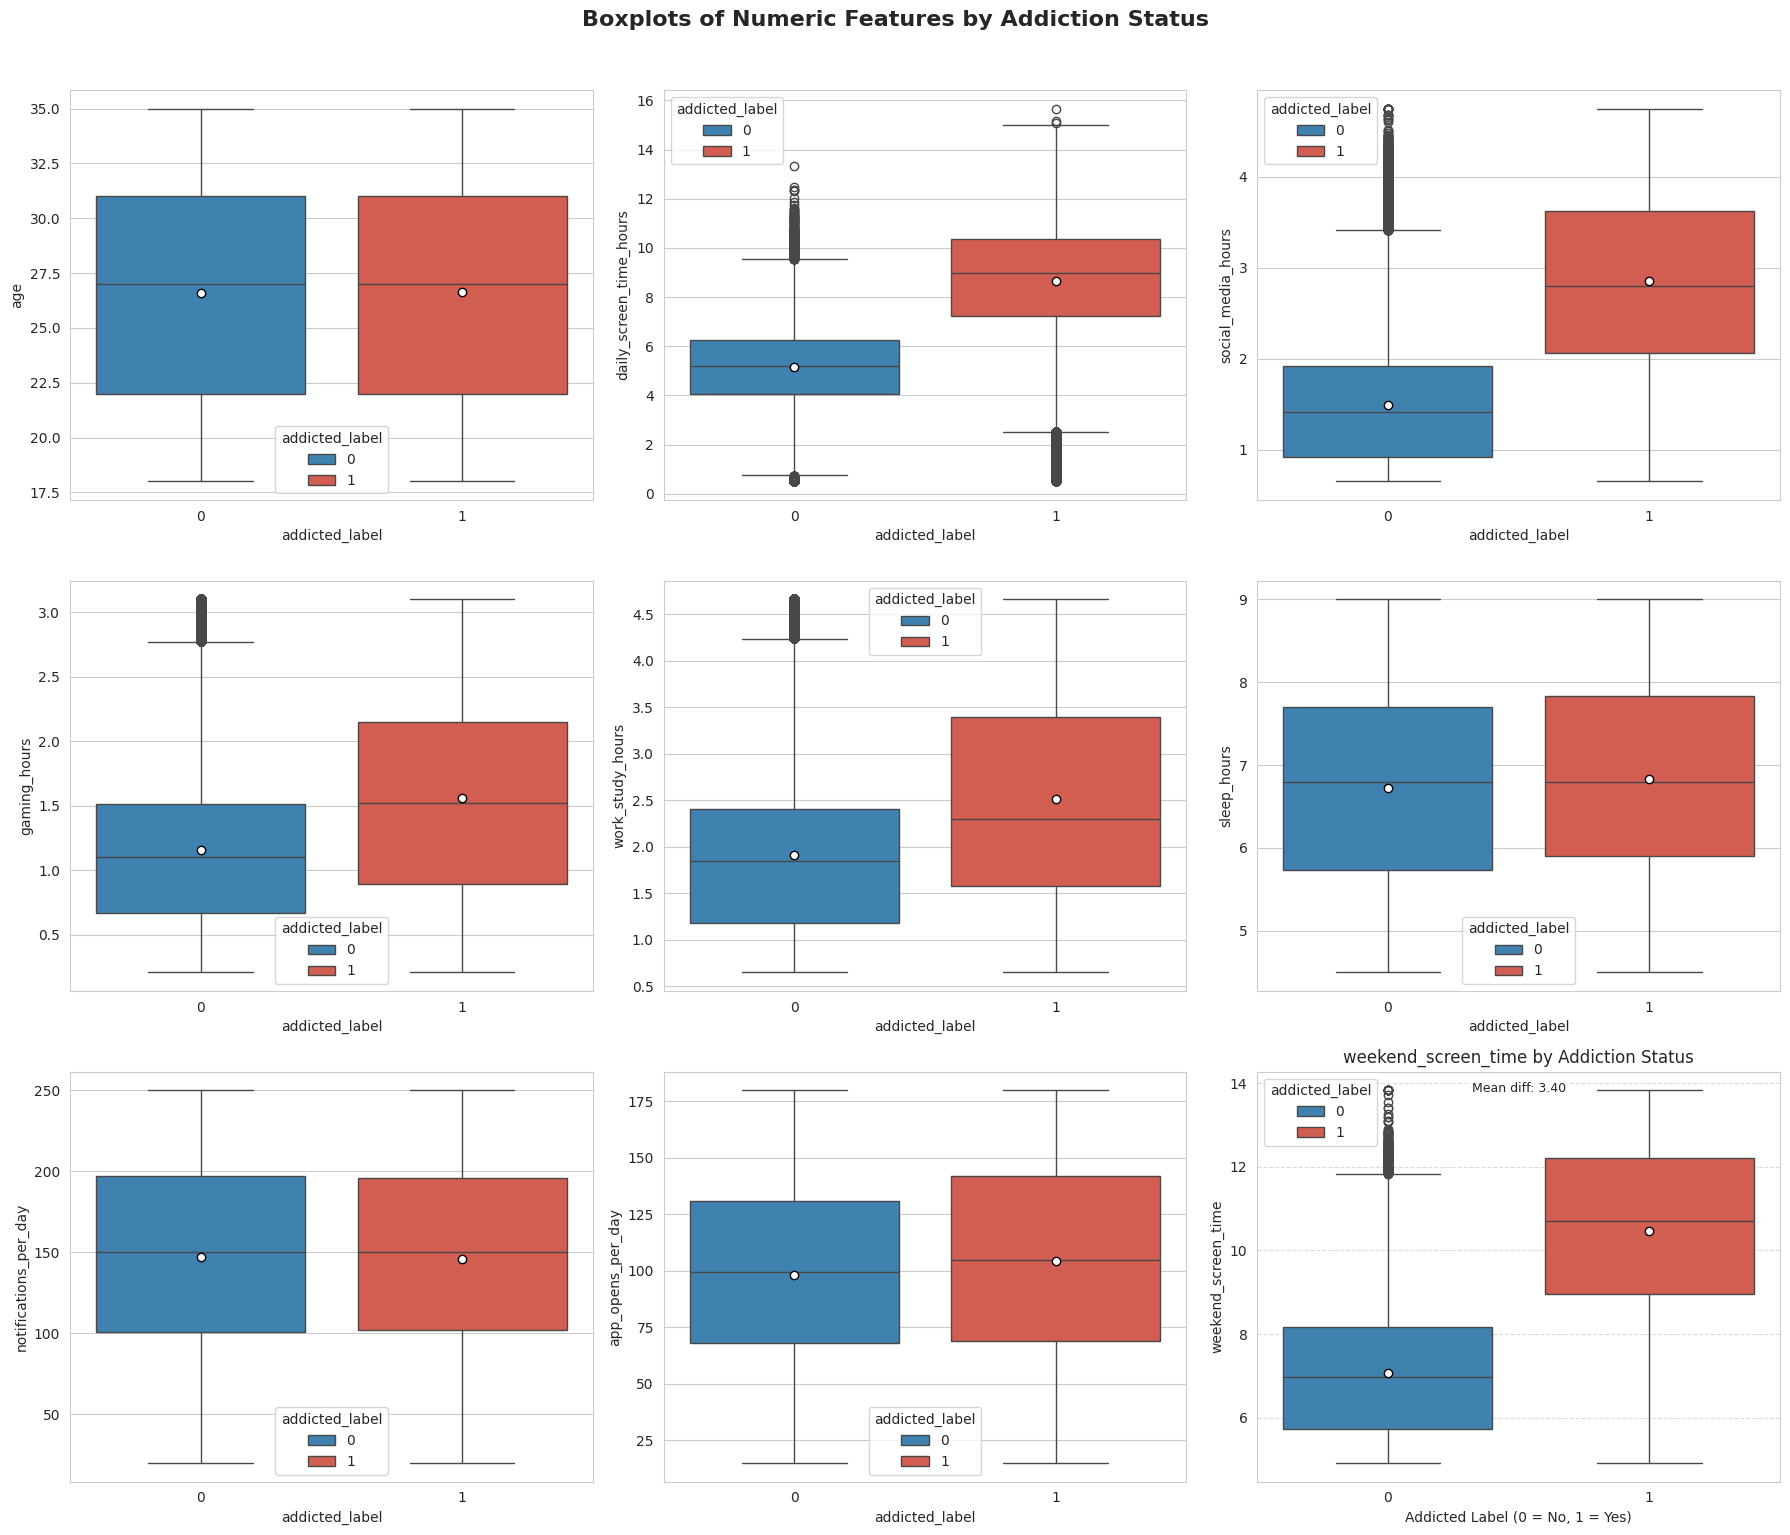

In [27]:
# 3.7 EDA against target variable
# 3.7.1 Boxplot of numeric features against target

num_cols_for_target = ['age', 'daily_screen_time_hours', 'social_media_hours',
                       'gaming_hours', 'work_study_hours', 'sleep_hours',
                       'notifications_per_day', 'app_opens_per_day',
                       'weekend_screen_time']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(num_cols_for_target):
    sns.boxplot(x='addicted_label', y=col, data=df,
                hue='addicted_label',
                palette=['#2E86C1', '#E74C3C'],
                ax=axes[i],
                legend=True,
                showmeans=True,
                meanprops={"marker":"o",
                          "markerfacecolor":"white",
                          "markeredgecolor":"black",
                          "markersize":"6"})

axes[i].set_title(f'{col} by Addiction Status', fontsize=12)
axes[i].set_xlabel('Addicted Label (0 = No, 1 = Yes)')
axes[i].set_ylabel(col)
axes[i].grid(axis='y', linestyle='--', alpha=0.7)


mean_0 = df[df['addicted_label'] == 0][col].mean()
mean_1 = df[df['addicted_label'] == 1][col].mean()
diff = mean_1 - mean_0
axes[i].annotate(f'Mean diff: {diff:.2f}',
                 xy=(0.5, 0.95),
                 xycoords='axes fraction',
                 fontsize=9,
                 ha='center',
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

if len(num_cols_for_target) < len(axes):
    for j in range(len(num_cols_for_target), len(axes)):
        fig.delaxes(axes[j])

plt.suptitle('Boxplots of Numeric Features by Addiction Status',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

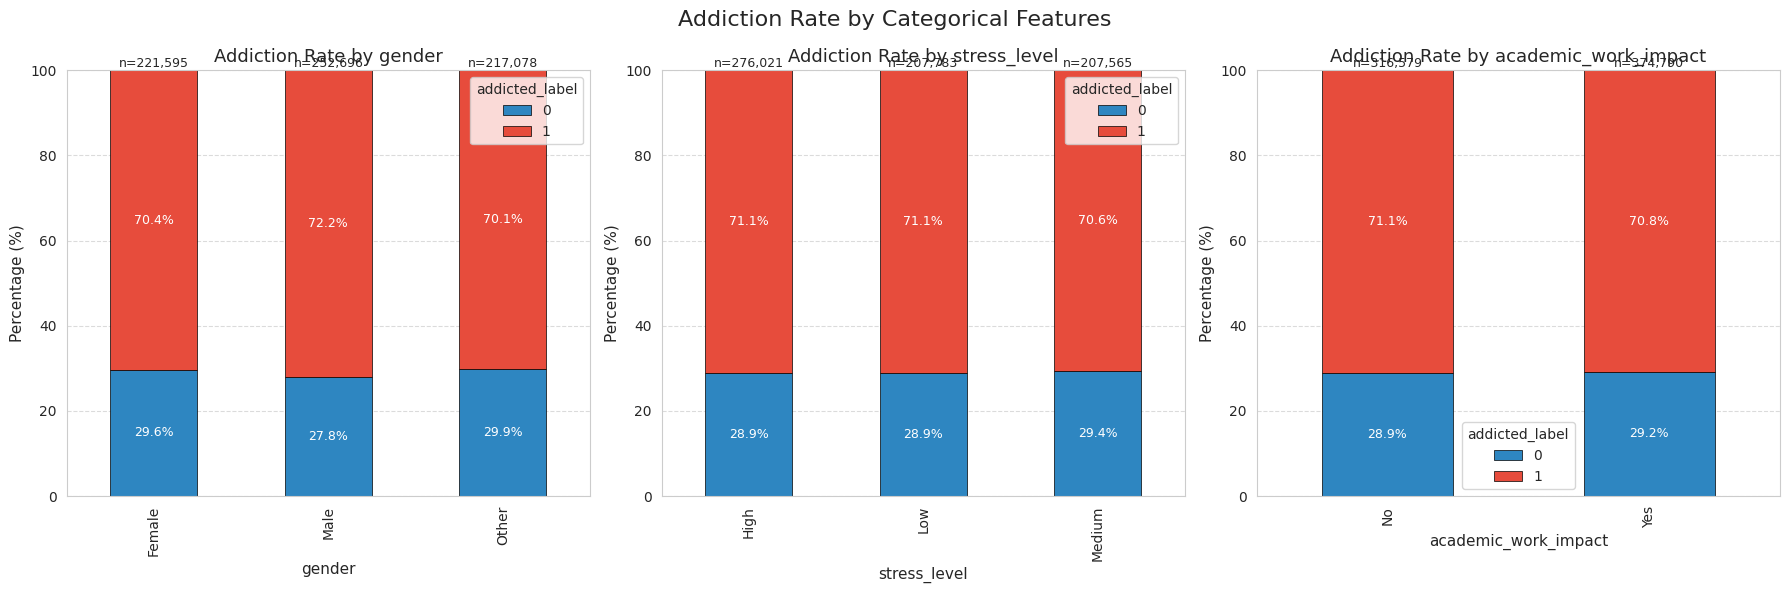

In [28]:
# 3.7.2 Grouped Bar Charts for Categorical Features by Target Variable

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, cat_col in enumerate(cat_cols):
    cross_tab = pd.crosstab(df[cat_col], df['addicted_label'])
    cross_tab_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100

    ax = cross_tab_pct.plot(kind='bar',
                           stacked=True,
                           ax=axes[i],
                           color=['#2E86C1', '#E74C3C'],
                           edgecolor='black',
                           linewidth=0.5,
                           legend=True)

    for idx, (index, row) in enumerate(cross_tab_pct.iterrows()):
        cumsum = 0
        for j, (col, val) in enumerate(row.items()):
            if val > 0:
                ax.text(idx, cumsum + val/2,
                       f'{val:.1f}%',
                       ha='center', va='center',
                       fontsize=9,
                       color='white' if val > 20 else 'black')
            cumsum += val

    axes[i].set_title(f'Addiction Rate by {cat_col}', fontsize=13)
    axes[i].set_xlabel(cat_col, fontsize=11)
    axes[i].set_ylabel('Percentage (%)', fontsize=11)
    axes[i].set_ylim(0, 100)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    for idx, (index, row) in enumerate(cross_tab.iterrows()):
        total = row.sum()
        axes[i].text(idx, 100, f'n={total:,}',
                     ha='center', va='bottom',
                     fontsize=9)

plt.suptitle('Addiction Rate by Categorical Features',
             fontsize=16)
plt.tight_layout()
plt.show()

gender, stress or academic work impact don't seem to be highly contributing to phone addiction


# 4. Feature Selection

In [29]:
# 4.1 Using Recursive Feature Elimination
# 4.1.1 Logistic Regression

features_to_use = ['age', 'daily_screen_time_hours', 'social_media_hours',
                   'gaming_hours', 'work_study_hours', 'sleep_hours',
                   'notifications_per_day', 'app_opens_per_day',
                   'weekend_screen_time', 'gender_encoded_Female', 'gender_encoded_Male',
                   'gender_encoded_Other', 'stress_level_encoded', 'academic_work_impact_n']

X = df_scaled[features_to_use]
y = df['addicted_label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

log_estimator = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)

rfe_log = RFE(estimator=log_estimator, n_features_to_select=8, step=1)
rfe_log.fit(X_train, y_train)

rfe_selected = X_train.columns[rfe_log.support_].tolist()
rfe_ranking = pd.DataFrame({
    "feature": X_train.columns,
    "selected": rfe_log.support_,
    "rank": rfe_log.ranking_
}).sort_values("rank")

print("RFE selected features:", rfe_selected)
rfe_ranking

RFE selected features: ['daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'weekend_screen_time', 'gender_encoded_Female', 'gender_encoded_Male', 'gender_encoded_Other']


,feature,selected,rank
1,daily_screen_time_hours,True,1
2,social_media_hours,True,1
3,gaming_hours,True,1
4,work_study_hours,True,1
11,gender_encoded_Other,True,1
10,gender_encoded_Male,True,1
9,gender_encoded_Female,True,1
8,weekend_screen_time,True,1
5,sleep_hours,False,2
7,app_opens_per_day,False,3


In [30]:
# 4.1.2 Evaluate RFE ranking

val_score = rfe_log.score(X_val, y_val)
print(f"Validation accuracy with selected features: {val_score:.4f}")

Validation accuracy with selected features: 0.8462


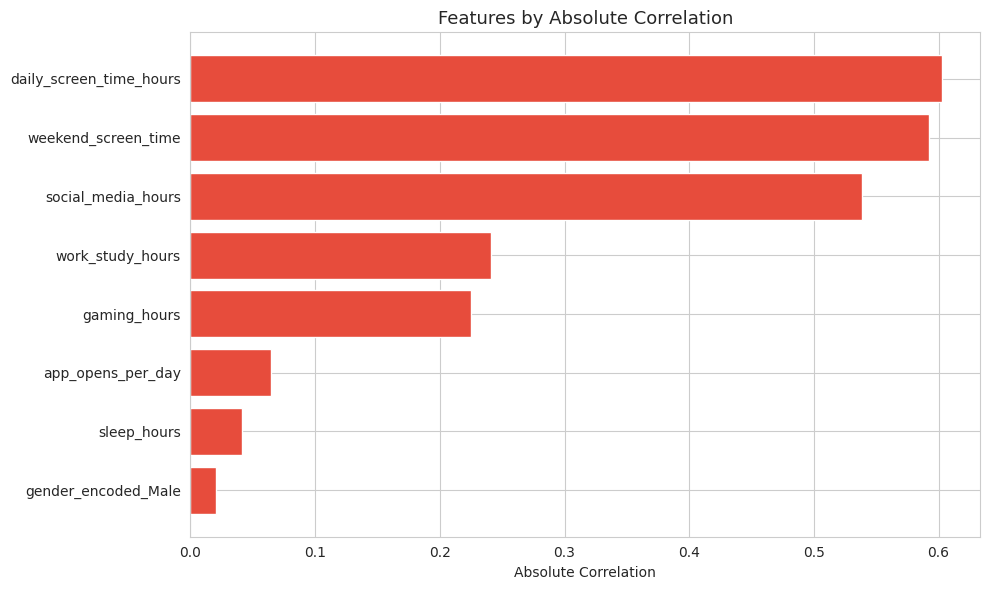

In [31]:
# 4.2 : Pearson Correlation
corr_with_target = X.corrwith(pd.Series(y))

p_corr = corr_with_target.abs().sort_values(ascending=False).head(8)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_with_target[p_corr.index]]
plt.barh(p_corr.index[::-1], p_corr.values[::-1], color=colors[::-1])
plt.title('Features by Absolute Correlation', fontsize=13)
plt.xlabel('Absolute Correlation')
plt.tight_layout()
plt.show()

In [32]:
# 4.2 Final feature selection
common_features = list(set(p_corr.index) & set(rfe_ranking['feature']))

print(f"Selected features ({len(common_features)}):")
print(common_features)

Selected features (8):
['sleep_hours', 'app_opens_per_day', 'social_media_hours', 'daily_screen_time_hours', 'work_study_hours', 'gender_encoded_Male', 'gaming_hours', 'weekend_screen_time']


In [61]:
selected_features = ['social_media_hours', 'work_study_hours', 'gaming_hours',
                     'sleep_hours', 'daily_screen_time_hours', 'weekend_screen_time',
                     'app_opens_per_day']

df_features = df_scaled[selected_features]

print(f'Features Selected')

Features Selected


# 5. Model Building

In [62]:
# 5.0.1 assign variables and split for train and validation
X = df_features
y = df['addicted_label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3,random_state=42)

X_train = X_train.astype('float32')
X_val = X_val.astype('float32')

In [77]:
# 5.0.2 evaluation function

def evaluate(y_true, y_pred, model_name):
  acc = accuracy_score(y_true, y_pred)
  auc = roc_auc_score(y_true, y_pred)
  cr = classification_report(y_true, y_pred,
                             labels=[0, 1],
                             target_names=['Not Addicted (0)', 'Addicted (1)'],
                             output_dict=True)
  cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

  print(f'=== Model Performance ===')
  print(f'{model_name}')
  print(f'=========================')
  print(f'Accuracy: {acc:.2%}')
  print(f'ROC-AUC: {auc:.3f}\n')
  print(f'=== Classification Report ===')
  print(classification_report(y_true,
                              y_pred,
                              labels=[0, 1],
                              target_names=['Not Addicted (0)', 'Addicted (1)']))

  fig, ax = plt.subplots(figsize=(6, 5))
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Addicted", "Addicted"])
  disp.plot(cmap="Blues", ax=ax, values_format="d")
  plt.title('Confusion Matrix')
  plt.grid(False)
  plt.show()

  return {
      'Model': model_name,
      'Accuracy (%)': round(acc * 100, 2),
      'ROC-AUC': round(auc, 3),
      'Precision (Addicted)': round(cr['Addicted (1)']['precision'], 2),
      'Recall (Addicted)': round(cr['Addicted (1)']['recall'], 2),
      'F1 (Addicted)': round(cr['Addicted (1)']['f1-score'], 2)
  }

print('Evaluation function ready')

Evaluation function ready


=== Model Performance ===
Linear Regression
Accuracy: 83.81%
ROC-AUC: 0.846

=== Classification Report ===
                  precision    recall  f1-score   support

Not Addicted (0)       0.67      0.86      0.76     60444
    Addicted (1)       0.94      0.83      0.88    146967

        accuracy                           0.84    207411
       macro avg       0.80      0.85      0.82    207411
    weighted avg       0.86      0.84      0.84    207411



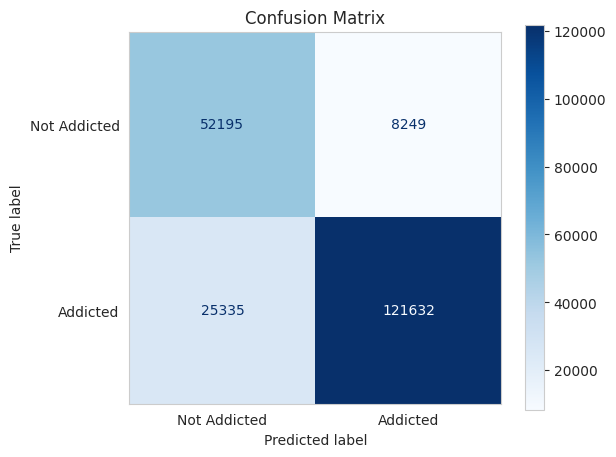

In [78]:
# 5.1 Logistic Regression

lr = LogisticRegression(max_iter=1000, random_state=42,
                        class_weight='balanced')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_val)
y_prob_lr = lr.predict_proba(X_val)[:, 1]

res_lr = evaluate(y_val, y_pred_lr, 'Linear Regression')

=== Model Performance ===
LightGBM
Accuracy: 87.92%
ROC-AUC: 0.846

=== Classification Report ===
                  precision    recall  f1-score   support

Not Addicted (0)       0.81      0.77      0.79     60444
    Addicted (1)       0.91      0.92      0.92    146967

        accuracy                           0.88    207411
       macro avg       0.86      0.85      0.85    207411
    weighted avg       0.88      0.88      0.88    207411



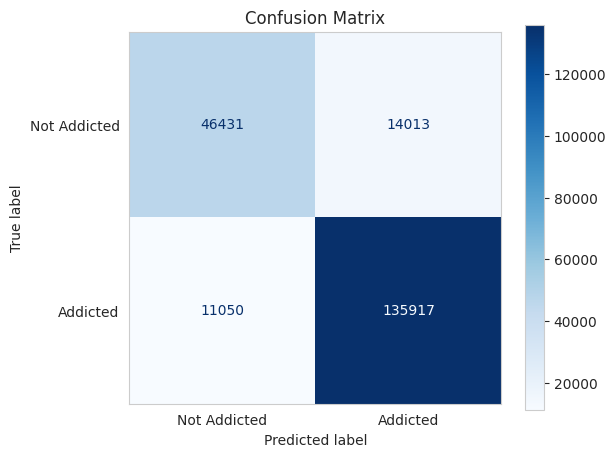

In [79]:
# 5.2 LightGBM

lgbm = LGBMClassifier(random_state=42, n_jobs=-1)
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_val)
y_prob_lgbm = lgbm.predict_proba(X_val)[:, 1]

res_lgbm = evaluate(y_val, y_pred_lgbm, 'LightGBM')

=== Model Performance ===
Decision Tree Classifier
Accuracy: 86.07%
ROC-AUC: 0.822

=== Classification Report ===
                  precision    recall  f1-score   support

Not Addicted (0)       0.78      0.73      0.75     60444
    Addicted (1)       0.89      0.91      0.90    146967

        accuracy                           0.86    207411
       macro avg       0.84      0.82      0.83    207411
    weighted avg       0.86      0.86      0.86    207411



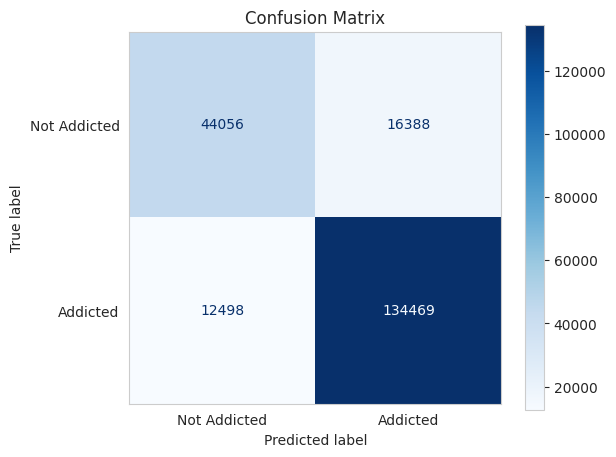

In [80]:
# 5.3 Decision Tree

dt = DecisionTreeClassifier(random_state=42, max_depth=12, min_samples_leaf=50)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_val)
y_prob_dt = dt.predict_proba(X_val)[:, 1]

res_dt = evaluate(y_val, y_pred_dt, 'Decision Tree Classifier')

=== Model Performance ===
Random Forest Classifier
Accuracy: 86.19%
ROC-AUC: 0.824

=== Classification Report ===
                  precision    recall  f1-score   support

Not Addicted (0)       0.78      0.73      0.76     60444
    Addicted (1)       0.89      0.91      0.90    146967

        accuracy                           0.86    207411
       macro avg       0.84      0.82      0.83    207411
    weighted avg       0.86      0.86      0.86    207411



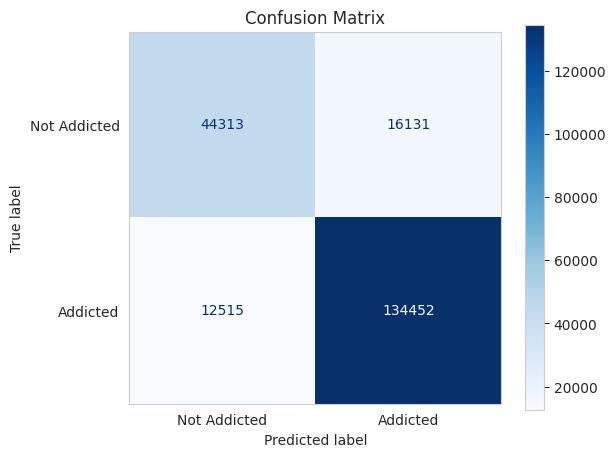

In [81]:
# 5.4 Random Forest

X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=50000,
                                       stratify=y_train, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                             max_depth=12, min_samples_leaf=50)
rf.fit(X_sub, y_sub)

y_pred_rf = rf.predict(X_val)
y_prob_rf = rf.predict_proba(X_val)[:, 1]

res_rf = evaluate(y_val, y_pred_rf, 'Random Forest Classifier')

=== Model Performance ===
XGBoost Classifier
Accuracy: 88.31%
ROC-AUC: 0.851

=== Classification Report ===
                  precision    recall  f1-score   support

Not Addicted (0)       0.81      0.78      0.79     60444
    Addicted (1)       0.91      0.93      0.92    146967

        accuracy                           0.88    207411
       macro avg       0.86      0.85      0.86    207411
    weighted avg       0.88      0.88      0.88    207411



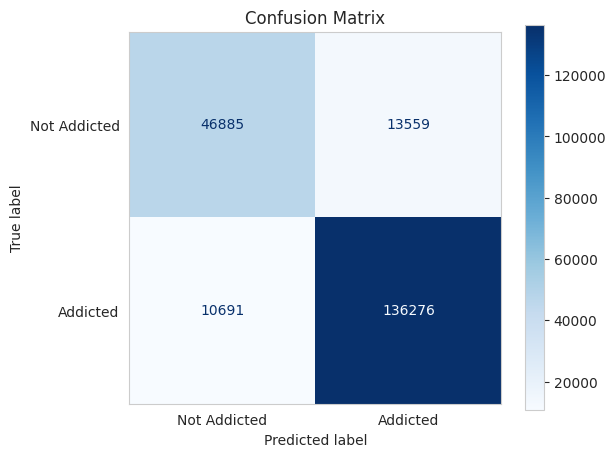

In [82]:
# 5.5 XGBoost

xgb = XGBClassifier(random_state=42, n_jobs=-1, tree_method='hist', device='cuda')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_val)
y_prob_xgb = xgb.predict_proba(X_val)[:, 1]

res_xgb = evaluate(y_val, y_pred_xgb, 'XGBoost Classifier')

In [85]:
# 5.7 Consolidated evaluation results

results_list = [res_lr, res_dt, res_rf, res_lgbm, res_xgb]

results_before = pd.DataFrame(results_list)
results_before = results_before.sort_values(by='F1 (Addicted)', ascending=False)

print('=== Model Comparison (All Models) ===\n')
display(results_before)

best_model_row = results_before.iloc[0]
print(f"\nBest Model: {best_model_row['Model']}")

=== Model Comparison (All Models) ===



,Model,Accuracy (%),ROC-AUC,Precision (Addicted),Recall (Addicted),F1 (Addicted)
4,XGBoost Classifier,88.31,0.851,0.91,0.93,0.92
3,LightGBM,87.92,0.846,0.91,0.92,0.92
2,Random Forest Classifier,86.19,0.824,0.89,0.91,0.90
1,Decision Tree Classifier,86.07,0.822,0.89,0.91,0.90
0,Linear Regression,83.81,0.846,0.94,0.83,0.88



Best Model: XGBoost Classifier


# 6. Model Optimization

Fitting 3 folds for each of 25 candidates, totalling 75 fits
=== Model Performance ===
XGBoost Classifier
Accuracy: 88.19%
ROC-AUC: 0.851

=== Classification Report ===
                  precision    recall  f1-score   support

Not Addicted (0)       0.81      0.78      0.79     60444
    Addicted (1)       0.91      0.92      0.92    146967

        accuracy                           0.88    207411
       macro avg       0.86      0.85      0.86    207411
    weighted avg       0.88      0.88      0.88    207411



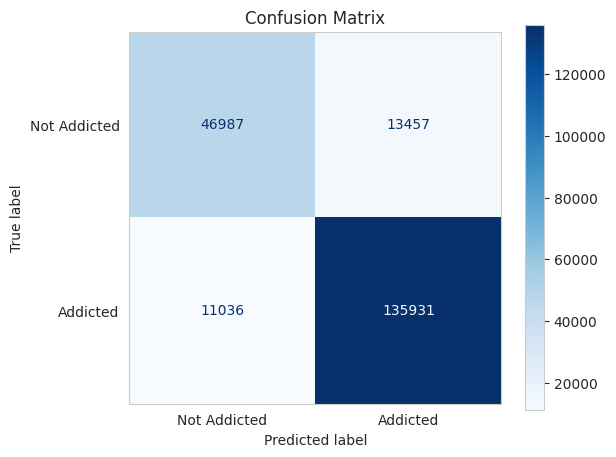

In [86]:
# 6.1 XGBoost Optimization

kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    device='cuda',
    random_state=42,
    n_jobs=-1
)

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_grid = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_grid,
    n_iter=25,
    scoring='f1',
    cv=kf,
    n_jobs=1,
    verbose=1,
    random_state=42,
    return_train_score=False
)

xgb_grid.fit(X_sub, y_sub)

best_xgb = xgb_grid.best_estimator_
best_xgb.fit(X_train, y_train)

y_pred_xgb_tuned = best_xgb.predict(X_val)
y_prob_xgb_tuned = best_xgb.predict_proba(X_val)[:, 1]

res_xgb_tuned = evaluate(y_val, y_pred_xgb_tuned, 'XGBoost Classifier')

Fitting 3 folds for each of 25 candidates, totalling 75 fits
=== Model Performance ===
LightGBM Classifier
Accuracy: 87.33%
ROC-AUC: 0.838

=== Classification Report ===
                  precision    recall  f1-score   support

Not Addicted (0)       0.80      0.75      0.78     60444
    Addicted (1)       0.90      0.92      0.91    146967

        accuracy                           0.87    207411
       macro avg       0.85      0.84      0.84    207411
    weighted avg       0.87      0.87      0.87    207411



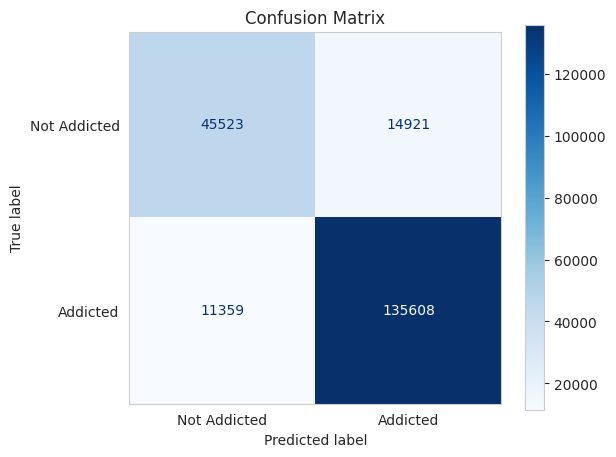

In [87]:
# 6.3 LightGBM Optimization

lgbm_model = LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_param_grid = {
    'n_estimators': [100, 200, 300],
    'num_leaves': [31, 50, 70, 90],
    'max_depth': [-1, 6, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

lgbm_grid = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=lgbm_param_grid,
    n_iter=25,
    scoring='f1',
    cv=kf,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=False
)

lgbm_grid.fit(X_sub, y_sub)

best_lgbm = lgbm_grid.best_estimator_
best_lgbm.fit(X_train, y_train)

y_pred_lgbm_tuned = best_lgbm.predict(X_val)
y_prob_lgbm_tuned = best_lgbm.predict_proba(X_val)[:, 1]

res_lgbm_tuned = evaluate(y_val, y_pred_lgbm_tuned, 'LightGBM Classifier')

In [88]:
# 6.3 Consolidated results

results_list = [res_lgbm_tuned, res_xgb_tuned]

results_after = pd.DataFrame(results_list)
results_after = results_after.sort_values(by='F1 (Addicted)', ascending=False)

print("\n=== Model Comparison (before tuning) ===")
display(results_before[0:2])

print("\n=== Model Comparison (after tuning) ===")
display(results_after)

best_model = results_after.iloc[0]['Model']
print(f"\nBest Model: {best_model}")


=== Model Comparison (before tuning) ===


,Model,Accuracy (%),ROC-AUC,Precision (Addicted),Recall (Addicted),F1 (Addicted)
4,XGBoost Classifier,88.31,0.851,0.91,0.93,0.92
3,LightGBM,87.92,0.846,0.91,0.92,0.92



=== Model Comparison (after tuning) ===


,Model,Accuracy (%),ROC-AUC,Precision (Addicted),Recall (Addicted),F1 (Addicted)
1,XGBoost Classifier,88.19,0.851,0.91,0.92,0.92
0,LightGBM Classifier,87.33,0.838,0.90,0.92,0.91



Best Model: XGBoost Classifier
